The purpose of this notebook is to be a scratchpad for testing out methods of correcting the ADV data with prongs that moved throughout the deployment. 

Those pesky ADVs are:
- VE7
- VE4
- VB5

In [1]:
# load the pesky advs but also load VE10, our "good ADV" that will be our control
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from granolas import multi_spectrogram, wavenumber_from_freq

QC_DIR = '../data/processed/qc'
RHO, G = 1025.0, 9.81
FMIN, FMAX = 0.04, 0.25      # sea-swell band [Hz], same as initial_figs

PESKY = ['VE4', 'VE7', 'VB5']
REFS  = ['VE10', 'VC5']      # VC5 is a second control: VE10's Dm already reads ~15 deg low vs the other 10 m sensors
qc = {S: xr.open_dataset(f'{QC_DIR}/{S}_QC.nc') for S in PESKY + REFS}   # lazy, 2 Hz

# head-motion events from adv_head_motion.ipynb (steps, tilt, low coherence)
events = {S: pd.read_csv(f'{QC_DIR}/headmotion/{S}_headmotion_events.csv', parse_dates=['time', 'end']) for S in PESKY}

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.linewidth': 0.8,
                     'axes.titlesize': 13, 'legend.frameon': False, 'lines.linewidth': 1.0})
COLOR = {'VE4': 'indianred', 'VE4fix': '#0047AB', 'VE10': '0.15', 'VC5': '#708238'}


# take specra using granolas
# hourly spectra + Dm already made with granolas in initial_figs.ipynb ({S}_spec.nc), so just load them here.
# coherence needs the quadrature spectra, which those files don't keep -> recomputed further down for VE4 only.
spec = {S: xr.load_dataset(f'{QC_DIR}/{S}_spec.nc') for S in PESKY + REFS}

# VE4

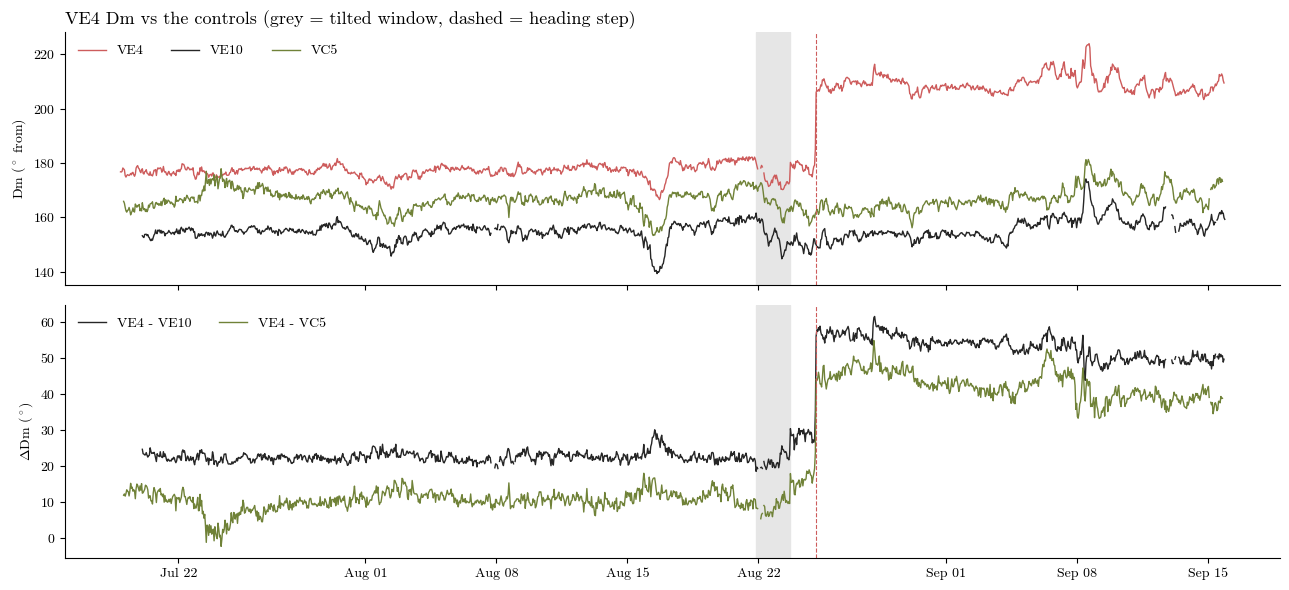

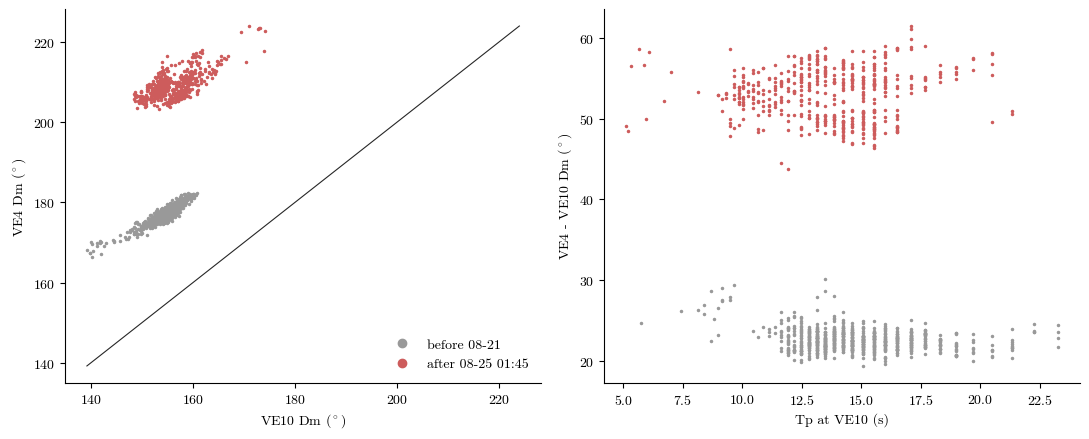

In [2]:
# plot VE4 vs VE10 Dmean

# ============ INPUTS ============
STEP = pd.Timestamp('2026-08-25 01:45')                                       # big heading step (adv_head_motion)
TILT = (pd.Timestamp('2026-08-21 20:20'), pd.Timestamp('2026-08-23 16:45'))   # tilted, low-coherence window
# ================================

dm = pd.DataFrame({S: spec[S].Dm.to_series() for S in ['VE4', 'VE10', 'VC5']})
dm['Tp'] = spec['VE10'].Tp.to_series()
dm['dDm_VE10'] = (dm.VE4 - dm.VE10 + 180) % 360 - 180      # wrapped to +-180
dm['dDm_VC5']  = (dm.VE4 - dm.VC5 + 180) % 360 - 180
before = dm.index < TILT[0]
after  = dm.index >= STEP

fig, axs = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for S in ['VE4', 'VE10', 'VC5']:
    axs[0].plot(dm.index, dm[S], color=COLOR[S], label=S)
axs[1].plot(dm.index, dm.dDm_VE10, color='0.15', label='VE4 - VE10')
axs[1].plot(dm.index, dm.dDm_VC5, color='#708238', label='VE4 - VC5')
for ax in axs:
    ax.axvline(STEP, color='indianred', ls='--', lw=0.8)
    ax.axvspan(*TILT, color='0.9')
axs[0].set_ylabel(r'Dm ($^\circ$ from)')
axs[1].set_ylabel(r'$\Delta$Dm ($^\circ$)')
axs[0].legend(ncol=3, loc='upper left')
axs[1].legend(ncol=2, loc='upper left')
axs[0].set_title('VE4 Dm vs the controls (grey = tilted window, dashed = heading step)', loc='left')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.tight_layout()
plt.show()

# the two clusters, and is the shift the same at every wave period? (a head rotation should be; refraction wouldn't)
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].plot(dm.VE10[before], dm.VE4[before], '.', ms=3, color='0.6', label=f'before {TILT[0]:%m-%d}')
axs[0].plot(dm.VE10[after], dm.VE4[after], '.', ms=3, color='indianred', label=f'after {STEP:%m-%d %H:%M}')
lims = [dm[['VE4', 'VE10']].min().min(), dm[['VE4', 'VE10']].max().max()]
axs[0].plot(lims, lims, color='0.15', lw=0.8)
axs[0].set_xlabel(r'VE10 Dm ($^\circ$)')
axs[0].set_ylabel(r'VE4 Dm ($^\circ$)')
axs[0].legend(markerscale=4)
axs[1].plot(dm.Tp[before], dm.dDm_VE10[before], '.', ms=3, color='0.6')
axs[1].plot(dm.Tp[after], dm.dDm_VE10[after], '.', ms=3, color='indianred')
axs[1].set_xlabel('Tp at VE10 (s)')
axs[1].set_ylabel(r'VE4 - VE10 Dm ($^\circ$)')
fig.tight_layout()
plt.show()

In [3]:
# the plot shows two clusters. This makes me think a constant offset can be applied
# OFFSET = (VE4 - VE10 Dm before the problem) - (VE4 - VE10 Dm after the step). Using the CHANGE in the
# difference means VE10's own ~15 deg bias and the 4 m vs 10 m refraction cancel out.

# ============ INPUTS ============
BASE = ('2026-07-23 17:00', '2026-08-20 18:00')   # last stable stretch with the head as deployed
FIT   = (STEP, '2026-09-16')                      # period the offset is fit over
APPLY = (STEP, '2026-09-16')                      # period the offset is applied to
TEST  = '2026-09-04'                              # out-of-sample check: fit before TEST, test after
# ================================

OFFSET    = dm.dDm_VE10[BASE[0]:BASE[1]].median() - dm.dDm_VE10[FIT[0]:FIT[1]].median()
OFFSET_C5 = dm.dDm_VC5[BASE[0]:BASE[1]].median()  - dm.dDm_VC5[FIT[0]:FIT[1]].median()
step_24h  = dm.dDm_VE10[STEP - pd.Timedelta('24h'):STEP].median() - dm.dDm_VE10[STEP:STEP + pd.Timedelta('24h')].median()
print(f'OFFSET from VE10:           {OFFSET:6.1f} deg   <- used')
print(f'OFFSET from VC5:            {OFFSET_C5:6.1f} deg')
print(f'24 h either side of step:   {step_24h:6.1f} deg   (adv_head_motion: -27.6 step, ~-32 total)')

# out-of-sample: fit on STEP -> TEST only, then see how far off it is after TEST
base       = dm.dDm_VE10[BASE[0]:BASE[1]].median()
offset_early = base - dm.dDm_VE10[STEP:TEST].median()
late_resid   = dm.dDm_VE10[TEST:FIT[1]].median() + offset_early - base
print(f'fit on {STEP:%m-%d} -> {TEST[5:]} only: {offset_early:6.1f} deg, leaves {late_resid:+.1f} deg after {TEST[5:]}')


# aooly a constant offset to the problem time period
# rotate the 2 Hz east/north velocities by OFFSET after the step (compass sense: + turns the vector clockwise),
# then remake the shore-normal u, v the same way adv_QC does. w and p are untouched.
ds = qc['VE4'][['p', 'u', 'v', 'u_east', 'v_north', 'seg_ok', 'depth_h']].load()
in_fix = ((ds.time >= pd.Timestamp(APPLY[0])) & (ds.time <= pd.Timestamp(APPLY[1]))).values
c  = np.radians(OFFSET)
E  = ds.u_east.values
N  = ds.v_north.values
E_fix = np.where(in_fix,  E * np.cos(c) + N * np.sin(c), E)
N_fix = np.where(in_fix, -E * np.sin(c) + N * np.cos(c), N)

sn = np.radians(qc['VE4'].attrs['rot_shore_normal_deg'])     # transect E onshore = 3 deg true
fix = ds.copy()
fix['u_east']  = ('time', E_fix)
fix['v_north'] = ('time', N_fix)
fix['u'] = ('time',  E_fix * np.sin(sn) + N_fix * np.cos(sn))   # cross-shore, + onshore
fix['v'] = ('time', -E_fix * np.cos(sn) + N_fix * np.sin(sn))   # alongshore, + toward 273
qc['VE4fix'] = fix          # corrected VE4, in memory only (nothing written to disk)
# the tilted window (TILT) is masked out in the spectra below; the 08-23 -> 08-25 stretch is left as is

OFFSET from VE10:            -31.1 deg   <- used
OFFSET from VC5:             -31.5 deg
24 h either side of step:    -27.9 deg   (adv_head_motion: -27.6 step, ~-32 total)
fit on 08-25 -> 09-04 only:  -32.6 deg, leaves -4.6 deg after 09-04


In [4]:
# spectra with coherence (granolas multi_spectrogram), for raw VE4, corrected VE4 and the two controls.
# Dm is recomputed here from the rotated velocities, not by adding OFFSET to the old Dm. ~1 min.

# ============ INPUTS ============
SENSORS = ['VE4', 'VE4fix', 'VE10', 'VC5']
NPERSEG = 1024             # 512 s windows, 50 % overlap -> ~7 windows per hour
# ================================

hs = {}
for S in SENSORS:
    ds = qc[S]
    df = ds[['p', 'u', 'v', 'u_east', 'v_north']].to_dataframe()
    df['p_head'] = df.p * 1e4 / (RHO * G)                          # pressure head [m]
    xs = multi_spectrogram(df, columns=['p_head', 'u', 'v'],
                           pairs=[('p_head', 'u'), ('p_head', 'v'), ('p_head', 'u_east'), ('p_head', 'v_north')],
                           nperseg=NPERSEG, overlap_frac=0.5)
    del df

    # drop windows in hours that failed QC, and the tilted window (for every sensor, so all lines compare like with like)
    win_hour = pd.DatetimeIndex(xs.time.values).floor('h')
    ok = ds.seg_ok.to_series().reindex(win_hour).fillna(False).values.astype(bool)
    ok = ok & ~((win_hour >= TILT[0]) & (win_hour < TILT[1]))
    xs = xs.where(xr.DataArray(ok, dims='time'))
    xs = xs.resample(time='1h').mean()                             # hourly averages (coherence needs this)
    xs['h'] = ds.depth_h.rename(hour='time').reindex(time=xs.time)  # total water depth (mean p + sensor height), for k

    band = xs.sel(frequency=slice(FMIN, FMAX))
    toward = np.degrees(np.arctan2(band.Co_p_head_u_east.sum('frequency', min_count=1), band.Co_p_head_v_north.sum('frequency', min_count=1)))
    xs['Dm'] = (toward + 180) % 360                                # direction waves come FROM (min_count: masked hours stay NaN)
    xs['uv_ratio'] = band.S_u.sum('frequency', min_count=1) / band.S_v.sum('frequency', min_count=1)   # cross / alongshore energy

    # squared coherence per frequency, then a Spp-weighted mean over the band
    coh_pu  = (band.Co_p_head_u**2 + band.Quad_p_head_u**2) / (band.S_p_head * band.S_u)
    coh_pv  = (band.Co_p_head_v**2 + band.Quad_p_head_v**2) / (band.S_p_head * band.S_v)
    coh_tot = (band.Co_p_head_u**2 + band.Quad_p_head_u**2 + band.Co_p_head_v**2 + band.Quad_p_head_v**2) \
              / (band.S_p_head * (band.S_u + band.S_v))           # p vs the whole horizontal velocity: rotation-proof
    wt = band.S_p_head / band.S_p_head.sum('frequency')
    xs['coh_pu']  = (coh_pu * wt).sum('frequency', min_count=1)
    xs['coh_pv']  = (coh_pv * wt).sum('frequency', min_count=1)
    xs['coh_tot'] = (coh_tot * wt).sum('frequency', min_count=1)
    hs[S] = xs
    print(S, 'done')

VE4 done
VE4fix done
VE10 done
VC5 done


Dm - VE10  Suu/Svv  coh p-u  coh p-v
sensor period                                            
VE4    before            22.45    18.57     0.98     0.30
       after, early      55.00     3.89     0.97     0.85
       after, late       50.44     3.49     0.96     0.81
VE4fix before            22.45    18.57     0.98     0.30
       after, early      23.93    19.39     0.98     0.32
       after, late       19.37    12.65     0.97     0.26
VE10   before             0.00     3.01     0.97     0.88
       after, early       0.00     2.64     0.98     0.91
       after, late        0.00     3.59     0.98     0.79
VC5    before            11.86    17.42     0.97     0.15
       after, early      11.30    14.82     0.97     0.24
       after, late       10.31    14.29     0.97     0.16

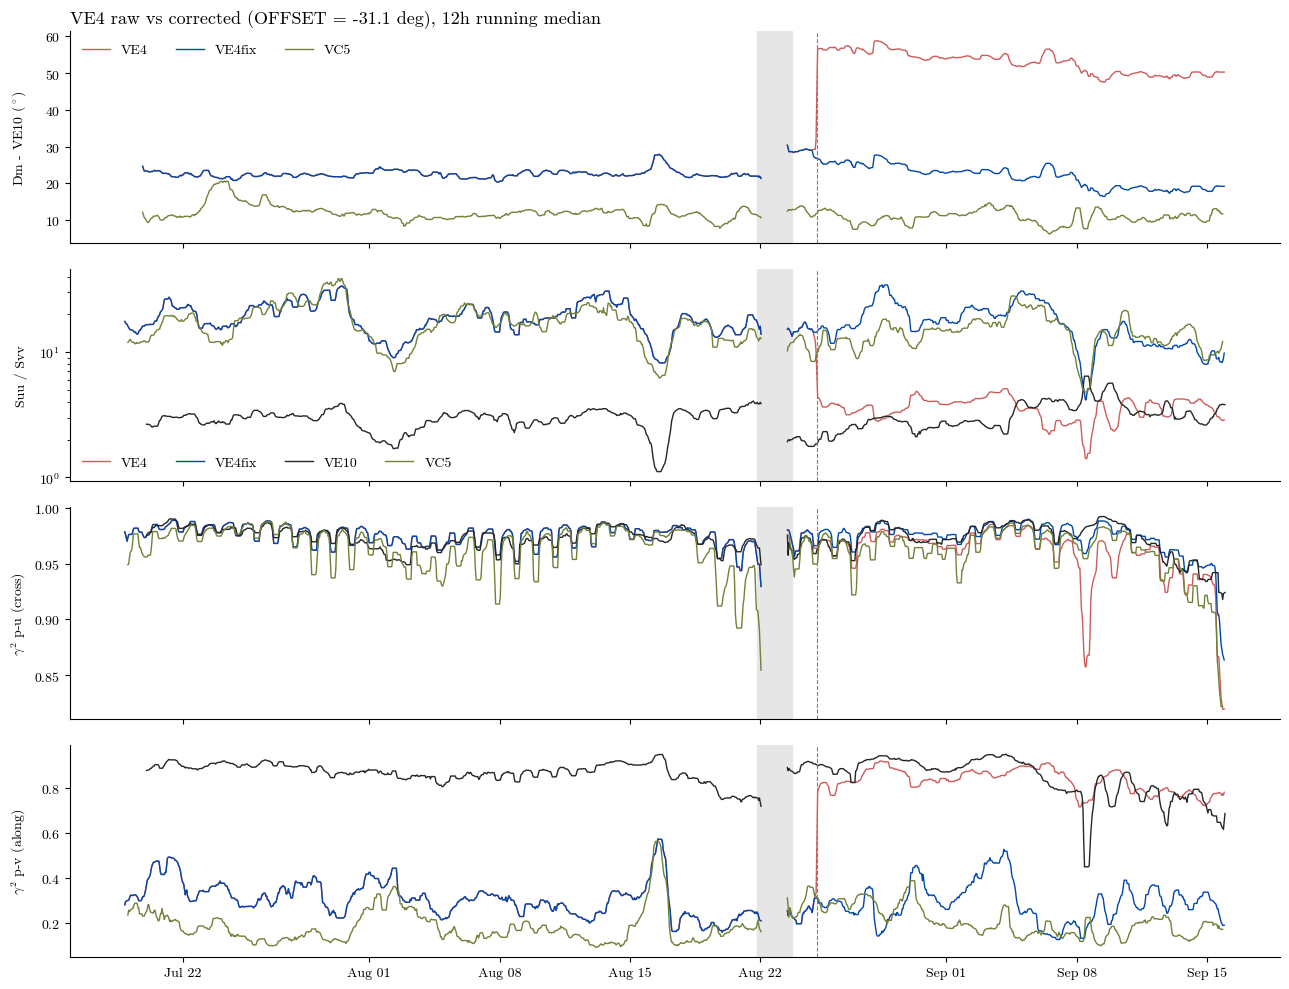

In [5]:
# Did the offset work? Checks that DO change with heading:
#  1. VE4 - VE10 Dm goes back to its pre-problem level, and stays there (fit 08-25 -> end, but look at early vs late)
#  2. cross/alongshore energy Suu/Svv and coherence p-u, p-v go back to their pre-problem levels.
#     These were NOT used to fit OFFSET, so they are an independent test.

# ============ INPUTS ============
PERIODS = {'before': BASE, 'after, early': (STEP, '2026-09-04'), 'after, late': ('2026-09-04', '2026-09-16')}
SMOOTH  = '12h'
# ================================

for S in hs:
    hs[S]['dDm'] = (hs[S].Dm - hs['VE10'].Dm + 180) % 360 - 180

rows = []
for S in ['VE4', 'VE4fix', 'VE10', 'VC5']:
    for name, (a, b) in PERIODS.items():
        x = hs[S].sel(time=slice(a, b))
        rows.append([S, name, float(x.dDm.median()), float(x.uv_ratio.median()), float(x.coh_pu.median()), float(x.coh_pv.median())])
table = pd.DataFrame(rows, columns=['sensor', 'period', 'Dm - VE10', 'Suu/Svv', 'coh p-u', 'coh p-v']).set_index(['sensor', 'period'])
display(table.round(2))

fig, axs = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for S in ['VE4', 'VE4fix', 'VE10', 'VC5']:
    x = hs[S][['dDm', 'uv_ratio', 'coh_pu', 'coh_pv']].to_dataframe().rolling(SMOOTH, center=True).median()
    if S != 'VE10':
        axs[0].plot(x.index, x.dDm, color=COLOR[S], label=S)
    axs[1].plot(x.index, x.uv_ratio, color=COLOR[S], label=S)
    axs[2].plot(x.index, x.coh_pu, color=COLOR[S])
    axs[3].plot(x.index, x.coh_pv, color=COLOR[S])
axs[0].set_ylabel(r'Dm - VE10 ($^\circ$)')
axs[1].set_ylabel('Suu / Svv')
axs[1].set_yscale('log')
axs[2].set_ylabel(r'$\gamma^2$ p-u (cross)')
axs[3].set_ylabel(r'$\gamma^2$ p-v (along)')
for ax in axs:
    ax.axvline(STEP, color='indianred', ls='--', lw=0.8)
    ax.axvspan(*TILT, color='0.9')
axs[0].legend(ncol=3, loc='upper left')
axs[1].legend(ncol=4, loc='lower left')
axs[0].set_title(f'VE4 raw vs corrected (OFFSET = {OFFSET:.1f} deg), {SMOOTH} running median', loc='left')
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.align_ylabels(axs)
fig.tight_layout()
plt.show()

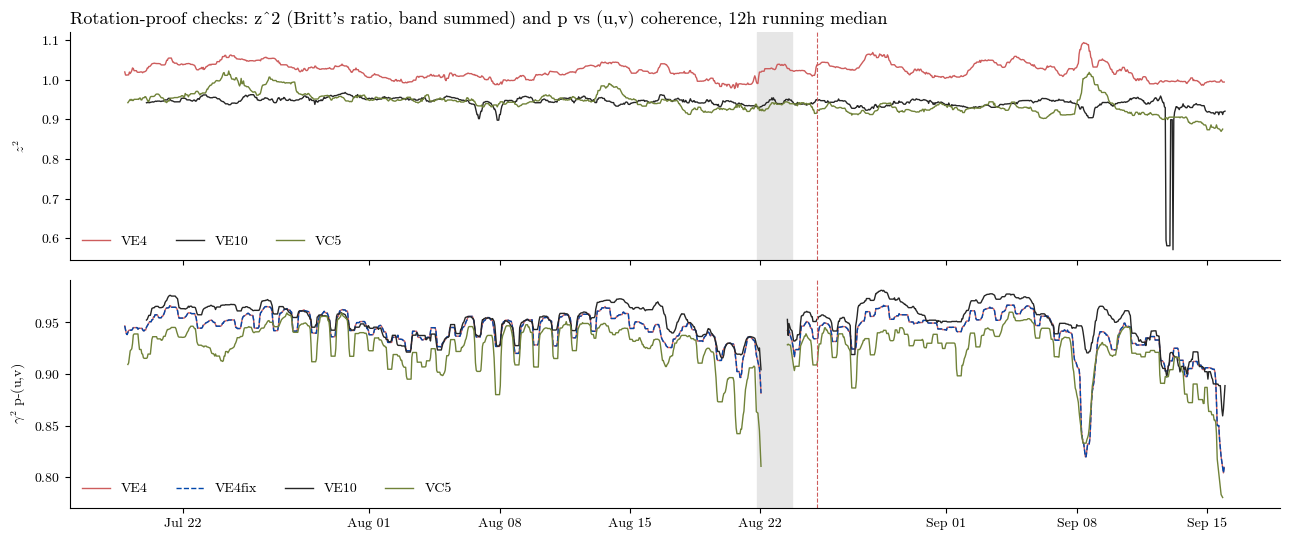

/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_76083/1080346509.py:43: RuntimeWarning: invalid value encountered in divide
  ratio = x.S_p_head.transpose('time', 'frequency') * (G * k / w)**2 / (x.S_u + x.S_v).transpose('time', 'frequency')
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_76083/1080346509.py:43: RuntimeWarning: invalid value encountered in divide
  ratio = x.S_p_head.transpose('time', 'frequency') * (G * k / w)**2 / (x.S_u + x.S_v).transpose('time', 'frequency')


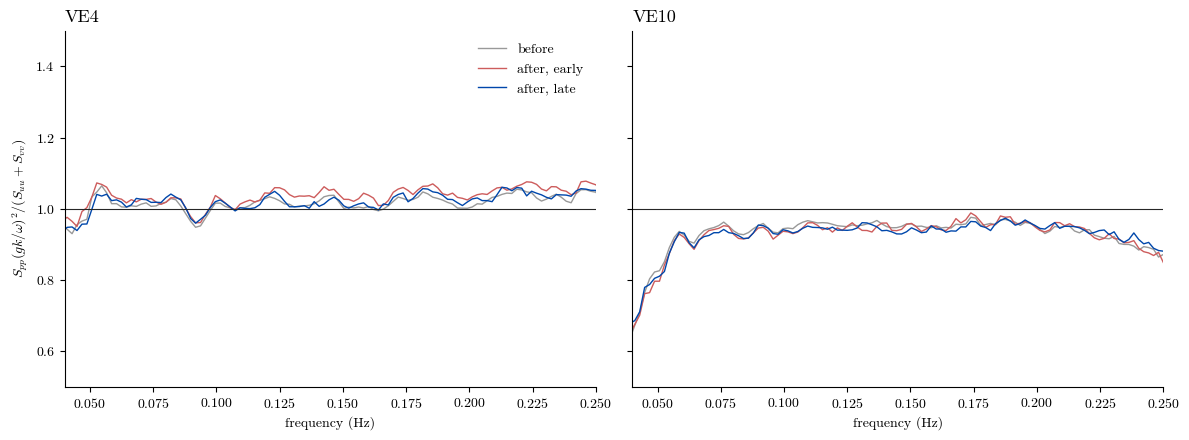

In [6]:
# this is what Britt wrote to me:
# I like your plan to look at p-u coherence … but I’d suggest ALSO looking at spectral ratios of p^2*(g/h) and u^2 (or u^2*h/g and p^2 where
# p^2 and u^2 are p and u sea-swell spectral levels or summed across the sea-swell frequencies) as well (linear theory suggests p^2*g/h ~ u^2 ….
# might want to do P^2/(U^2+V^2) (with appropriate constants to make u,v same as p.

# NOTE: P^2/(U^2+V^2) and the p coherence with the WHOLE horizontal velocity don't change when the head turns
# about the vertical, so they can't tell us whether OFFSET is right (raw and fixed VE4 lie on top of each other).
# What they DO tell us is whether the head still measures the right velocity size (not tilted or bent badly).
#  - band-summed ratio = the z^2 test already stored hourly in {S}_QC.nc (Elgar 2005, full linear transfer)
#  - per-frequency ratio with the full dispersion relation: Spp (g k / w)^2 / (Suu + Svv) = 1 for linear waves.
#    (g/h is the shallow-water limit; at 4 m it is already off by ~10 % at 0.2 Hz, so use k.)

# ============ INPUTS ============
SMOOTH = '12h'
# ================================

fig, axs = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
for S in ['VE4', 'VE10', 'VC5']:
    z2 = qc[S].z2.to_series().rolling(SMOOTH, center=True).median()
    axs[0].plot(z2.index, z2, color=COLOR[S], label=S)
for S in ['VE4', 'VE4fix', 'VE10', 'VC5']:
    ct = hs[S].coh_tot.to_series().rolling(SMOOTH, center=True).median()
    axs[1].plot(ct.index, ct, color=COLOR[S], label=S, ls='--' if S == 'VE4fix' else '-')
axs[0].set_ylabel(r'$z^2$')
axs[1].set_ylabel(r'$\gamma^2$ p-(u,v)')
for ax in axs:
    ax.axvline(STEP, color='indianred', ls='--', lw=0.8)
    ax.axvspan(*TILT, color='0.9')
axs[0].legend(ncol=3, loc='lower left')
axs[1].legend(ncol=4, loc='lower left')
axs[0].set_title(f'Rotation-proof checks: z^2 (Britt\'s ratio, band summed) and p vs (u,v) coherence, {SMOOTH} running median', loc='left')
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.align_ylabels(axs)
fig.tight_layout()
plt.show()

# per-frequency ratio, median over each period
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, S in zip(axs, ['VE4', 'VE10']):
    x = hs[S]
    k = wavenumber_from_freq(x.frequency.values[None, :], x.h.values[:, None])     # (time, frequency)
    w = 2 * np.pi * x.frequency.values[None, :]
    ratio = x.S_p_head.transpose('time', 'frequency') * (G * k / w)**2 / (x.S_u + x.S_v).transpose('time', 'frequency')
    for (name, (a, b)), color in zip(PERIODS.items(), ['0.6', 'indianred', '#0047AB']):
        r = ratio.sel(time=slice(a, b)).median('time')
        ax.plot(x.frequency, r, color=color, label=name)
    ax.axhline(1, color='0.15', lw=0.8)
    ax.set_xlim(FMIN, FMAX)
    ax.set_xlabel('frequency (Hz)')
    ax.set_title(S, loc='left')
axs[0].set_ylim(0.5, 1.5)
axs[0].set_ylabel(r'$S_{pp}(gk/\omega)^2 / (S_{uu}+S_{vv})$')
axs[0].legend()
fig.tight_layout()
plt.show()

## VE4 summary (2026-10-07)

**Offset:** −31.1° rotation of (u_east, v_north) from 08-25 01:45 to the end, fit as the change in VE4 − VE10 Dm against the 07-23 → 08-20 baseline. Against VC5 the same estimate is −31.5°. adv_head_motion found −27.6° for the step alone (this notebook: −27.9° from 24 h either side) and about −32° total. That total is the 08-23 rotation (~−6°) plus the 08-25 step. A drift of about +3–4° the other way after ~09-07 partly cancels it, so the full-period median comes out at −31°.

**Out-of-sample:** fit on 08-25 → 09-04 only, the offset is −32.6°, and it leaves −4.6° after 09-04. That is the same late drift.

**Checks that depend on the heading (these validate the offset):**

| | before (07-23 → 08-20) | after, early (08-25 → 09-04) | after, late (09-04 → end) |
|---|---|---|---|
| Dm − VE10, raw / fixed | 22.4° | 55.0° / **23.9°** | 50.4° / **19.4°** |
| Suu/Svv, raw / fixed (VC5) | 18.6 (17.4) | 3.9 / **19.4** (14.8) | 3.5 / **12.7** (14.3) |
| γ² p–v along, raw / fixed (VC5) | 0.30 (0.15) | 0.85 / **0.32** (0.24) | 0.81 / **0.26** (0.16) |

- Suu/Svv and p–v coherence come back to their pre-problem levels and track VC5. They follow the same wave direction relative to shore, so they don't confirm the size of the offset independently. What they do show: the distortion is a pure rotation, not a gain error on one arm or a tilt. The size of the offset rests on VE4 − VE10 Dm staying steady from the baseline to after the step. VE4 has no recovery +X-arm bearing, so there is no fully independent check.
- The shift is the same at all Tp (scatter figure), as a rotation should be. Refraction would depend on period.
- Remaining: after about 09-07 (the big swell) the corrected Dm − VE10 sits about 3–4° low, and VC5 − VE10 doesn't move as much. That is a small extra VE4 drift; one constant offset is good to about ±3–4°. Option, not applied: a second offset from ~09-07.

**Rotation-proof checks (Britt's ratio):** z² is about 1.02–1.03 in every period, including the tilted window. The per-frequency ratio Spp(gk/ω)²/(Suu+Svv) is the same before and after. The p–(u,v) coherence matches the controls. So after the step the head still measures the right horizontal velocity size; only its heading is wrong. These can't test the offset itself, because raw and fixed VE4 are identical in them.

**Not corrected:** 08-21 20:20 → 08-23 16:45 is masked (tilted window). 08-23 16:45 → 08-25 01:45 is left as is: Dm − VE10 is about 28°, so about 6° off.

# VE10

VE10's Dm reads ~155 deg, ~17 deg CCW of VD10 and ~28 deg off its own shore-normal (183 deg from), rotated *away* from it. Is VE10 measuring the right thing?
1. p^2/(u^2+v^2) through time (Britt's ratio, should be ~1 and steady)
2. p-u phasing: coherence, Spp/Suu, phase

**2026-10-08: `VE10_QC.nc` and `VE10_spec.nc` now carry a +17° heading fix** (adv_QC `HEADING_OVERRIDE`, KVH 343.0 → 0.0). The cells below up to the Snell figures were written and run with the old 343.0 heading. Rerun now, they show VE10 *after* the fix: `OFFSET10` prints the leftover against the other 10 m sensors, about −1.4°. The Snell figure cell takes the fix back out to show both.

In [ ]:
# VE10 + its neighbours at 10 m. Hourly auto- and cross-spectra of p, u, v, w (granolas multi_spectrogram, same
# windows as cell 5), kept per frequency so we can look at the ratio, coherence and phase. ~1 min per sensor.

# ============ INPUTS ============
SENSORS_10 = ['VE10', 'VD10', 'VC10']   # VD10 = nearest 10 m neighbour (~700 m west), VC10 = co-located with the Sig1000
NPERSEG    = 1024                       # 512 s windows, 50 % overlap -> ~7 windows per hour
# ================================

COLOR.update({'VD10': '#0047AB', 'VC10': '#708238'})
xs10 = {}
for S in SENSORS_10:
    ds = qc[S] if S in qc else xr.open_dataset(f'{QC_DIR}/{S}_QC.nc')
    df = ds[['p', 'u', 'v', 'w']].to_dataframe()
    df['p_head'] = df.p * 1e4 / (RHO * G)                          # pressure head [m]
    xs = multi_spectrogram(df, columns=['p_head', 'u', 'v', 'w'],
                           pairs=[('p_head', 'u'), ('p_head', 'v'), ('p_head', 'w')],
                           nperseg=NPERSEG, overlap_frac=0.5)
    del df

    win_hour = pd.DatetimeIndex(xs.time.values).floor('h')        # drop windows in hours that failed QC
    ok = ds.seg_ok.to_series().reindex(win_hour).fillna(False).values.astype(bool)
    xs = xs.where(xr.DataArray(ok, dims='time')).resample(time='1h').mean()
    xs['h'] = ds.depth_h.rename(hour='time').reindex(time=xs.time)  # total water depth, for k
    xs['z2_qc'] = ds.z2.rename(hour='time').reindex(time=xs.time)   # adv_QC's z^2, to check against
    xs10[S] = xs.load()
    print(S, 'done')

In [ ]:
# Test 1: p^2 / (u^2 + v^2) through time.
# Linear theory, p and u at the same height above the bed (both 5 cm here):
#     u_amp / p_head_amp = g k / w   ->   Spp (g k / w)^2 / (Suu + Svv) = 1   (any wave direction)
# (g/h is the shallow-water limit of (gk/w)^2.) Summed over the band this is the z^2 already in {S}_QC.nc, so z2_qc is
# drawn dashed as a check. The ratio uses u^2 + v^2, so it does NOT depend on heading: it tests the velocity SIZE
# (gain, tilt, a bent head), not the compass.

# ============ INPUTS ============
BAND   = (0.05, 0.20)   # Hz, same band as the z^2 gate in adv_QC
SMOOTH = '12h'
# ================================

for S, xs in xs10.items():
    b = xs.sel(frequency=slice(*BAND))
    k = wavenumber_from_freq(b.frequency.values[None, :], b.h.values[:, None])        # (time, frequency)
    w = 2 * np.pi * b.frequency.values[None, :]
    p_as_u = b.S_p_head.transpose('time', 'frequency') * (G * k / w)**2                 # Spp in velocity units
    xs['ratio'] = p_as_u.sum('frequency', min_count=1) / (b.S_u + b.S_v).sum('frequency', min_count=1)
    xs['ratio_f'] = p_as_u / (b.S_u + b.S_v).transpose('time', 'frequency')             # per frequency

fig, axs = plt.subplots(2, 1, figsize=(13, 6), sharex=True, height_ratios=[2, 1])
for S, xs in xs10.items():
    r = xs.ratio.to_series()
    axs[0].plot(r.index, r, color=COLOR[S], lw=0.4, alpha=0.4)
    axs[0].plot(r.index, r.rolling(SMOOTH, center=True).median(), color=COLOR[S], lw=1.4,
                label=f'{S}  median {r.median():.3f}')
    if S == 'VE10':
        axs[0].plot(xs.time, xs.z2_qc, color='indianred', ls='--', lw=0.8, label='VE10 z$^2$ from adv_QC')
    axs[1].plot(r.index, (r / xs10['VD10'].ratio.to_series().reindex(r.index)).rolling(SMOOTH, center=True).median(), color=COLOR[S])
axs[0].axhline(1, color='0.15', lw=0.8)
axs[0].set_ylim(0.5, 1.5)
axs[0].set_ylabel(r'$S_{pp}(gk/\omega)^2 / (S_{uu}+S_{vv})$')
axs[0].legend(ncol=4, loc='upper left')
axs[1].set_ylabel('ratio / VD10 ratio')
axs[0].set_title(f'p$^2$/(u$^2$+v$^2$), {BAND[0]}-{BAND[1]} Hz, hourly (thin) and {SMOOTH} running median (thick)', loc='left')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.align_ylabels(axs)
fig.tight_layout()
plt.show()

# per-frequency version: median over all good hours
fig, ax = plt.subplots(figsize=(7, 4))
for S, xs in xs10.items():
    ax.plot(xs.ratio_f.frequency, xs.ratio_f.median('time'), color=COLOR[S], label=S)
ax.axhline(1, color='0.15', lw=0.8)
ax.set_ylim(0.5, 1.5)
ax.set_xlabel('frequency (Hz)')
ax.set_ylabel(r'$S_{pp}(gk/\omega)^2 / (S_{uu}+S_{vv})$')
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
# Test 2: p-u phasing.
# For a PROGRESSIVE linear wave p and u are IN phase (0 deg: crest -> high p and onshore u at the same time).
# The 90 deg pair is p and w (w leads p by 90 deg). p-u near +-90 deg would mean a STANDING wave (strong reflection).
# p-v is 0 deg if waves lean west of shore-normal (v + toward 273 at transect E) and 180 deg if they lean east;
# its coherence grows with the angle off shore-normal.
# Phase = angle(conj(P) U), the multi_spectrogram convention: Co = Re, Quad = -Im -> phase = atan2(-Quad, Co).
# Averages are over all good hours (hourly coherence has ~7 windows, so gamma^2 is biased up by ~0.14 where it is low).

# ============ INPUTS ============
FPLOT = (0.004, 0.35)    # Hz, x-limits of the spectra
# ================================

fig, axs = plt.subplots(3, len(xs10), figsize=(15, 10), sharex=True, sharey='row')
for j, (S, xs) in enumerate(xs10.items()):
    m = xs.mean('time')                                     # deployment-mean auto/cross spectra (good hours only)
    f = m.frequency
    axs[0, j].loglog(f, m.S_p_head, color='0.15', label=r'$S_{pp}$ (m$^2$/Hz)')
    axs[0, j].loglog(f, m.S_u, color='indianred', label=r'$S_{uu}$ (m$^2$s$^{-2}$/Hz)')
    axs[0, j].loglog(f, m.S_v, color='#0047AB', label=r'$S_{vv}$')
    axs[0, j].loglog(f, m.S_w, color='#708238', label=r'$S_{ww}$')
    for pair, color in [('u', 'indianred'), ('v', '#0047AB'), ('w', '#708238')]:
        co, quad = xs[f'Co_p_head_{pair}'], xs[f'Quad_p_head_{pair}']
        coh = (co**2 + quad**2) / (xs.S_p_head * xs[f'S_{pair}'])
        axs[1, j].semilogx(f, coh.median('time'), color=color, label=f'p-{pair}')
        axs[2, j].semilogx(f, np.degrees(np.arctan2(-m[f'Quad_p_head_{pair}'], m[f'Co_p_head_{pair}'])),
                           color=color, label=f'p-{pair}')
    axs[0, j].set_title(S, loc='left')
    for ax in axs[:, j]:
        ax.axvspan(FMIN, FMAX, color='0.93', zorder=0)
for y in [-180, -90, 0, 90, 180]:
    for ax in axs[2]:
        ax.axhline(y, color='0.6', lw=0.6, zorder=0)
axs[0, 0].set_ylabel('spectral density')
axs[1, 0].set_ylabel(r'$\gamma^2$ (median of hourly)')
axs[2, 0].set_ylabel('phase (deg)')
axs[1, 0].set_ylim(0, 1)
axs[2, 0].set_ylim(-190, 190)
axs[2, 0].set_yticks([-180, -90, 0, 90, 180])
axs[0, 0].legend(loc='lower left')
axs[2, 0].legend(loc='lower left')
for ax in axs[2]:
    ax.set_xlabel('frequency (Hz)')
    ax.set_xlim(*FPLOT)
fig.tight_layout()
plt.show()

# band-averaged p-u coherence and phase through time (Spp-weighted, sea-swell band)
fig, axs = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
for S, xs in xs10.items():
    b = xs.sel(frequency=slice(FMIN, FMAX))
    coh = (b.Co_p_head_u**2 + b.Quad_p_head_u**2) / (b.S_p_head * b.S_u)
    wt = b.S_p_head / b.S_p_head.sum('frequency')
    coh_t = (coh * wt).sum('frequency', min_count=1).to_series()
    ph_t = pd.Series(np.degrees(np.arctan2(-b.Quad_p_head_u.sum('frequency', min_count=1),
                                           b.Co_p_head_u.sum('frequency', min_count=1))), index=xs.time.values)
    axs[0].plot(coh_t.index, coh_t, color=COLOR[S], label=S)
    axs[1].plot(ph_t.index, ph_t, color=COLOR[S], label=S)
axs[0].set_ylabel(r'$\gamma^2$ p-u')
axs[1].set_ylabel('phase p-u (deg)')
axs[1].axhline(0, color='0.15', lw=0.8)
axs[0].legend(ncol=3, loc='lower left')
axs[0].set_title(f'p-u coherence (Spp-weighted) and phase (band-summed co/quad), {FMIN}-{FMAX} Hz, hourly', loc='left')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.align_ylabels(axs)
fig.tight_layout()
plt.show()

In [ ]:
# VE10 heading check against VE4 (same transect, 4 m), using only the stretch before VE4's head moved.
# Refraction between 10 m and 4 m depends on wave period, so VE4 - VE10 Dm should change with Tp.
# A VE10 compass offset would be the same at every Tp.

# ============ INPUTS ============
CLEAN = ('2026-07-23 17:00', '2026-08-20 18:00')   # = BASE: VE4 head as deployed
TP_BINS = np.arange(8, 25, 2)                       # s
# ================================

d = dm.loc[CLEAN[0]:CLEAN[1], ['Tp', 'dDm_VE10']].dropna()
binned = d.groupby(pd.cut(d.Tp, TP_BINS)).dDm_VE10.agg(['median', 'count'])
slope = np.polyfit(d.Tp, d.dDm_VE10, 1)[0]
display(binned.round(1))
print(f'VE4 - VE10: median {d.dDm_VE10.median():.1f} deg, slope {slope:.2f} deg per s of Tp')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(d.Tp, d.dDm_VE10, '.', ms=3, color='0.6')
ax.plot([b.mid for b in binned.index], binned['median'], 'o-', color='indianred', label='binned median')
ax.set_xlabel('Tp at VE10 (s)')
ax.set_ylabel(r'VE4 - VE10 Dm ($^\circ$)')
ax.set_title(f'{CLEAN[0][:10]} to {CLEAN[1][:10]}, hourly', loc='left')
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
# Snell's law from VE10 (10 m) to VE4 (4 m), hourly, same clean stretch (CLEAN, from the cell above).
# Straight, parallel contours with transect E's shore-normal, waves at the VE10 Tp, phase speed c = w/k at each
# sensor's hourly mean depth:   sin(th4) = sin(th10) * c4 / c10,   th = Dm - shore-normal (from direction)
# Then the reverse: refract VE4 back out to 10 m and see what VE10 "should" read.

# ============ INPUTS ============
SN_FROM = (qc['VE10'].attrs['shore_normal_onshore_deg_true'] + 180) % 360   # 183 deg: shore-normal, as a "from" direction
# ================================

s = pd.DataFrame({'Dm10': spec['VE10'].Dm.to_series(), 'Dm4': spec['VE4'].Dm.to_series(), 'Tp': spec['VE10'].Tp.to_series(),
                  'h10': spec['VE10'].h_mean.to_series(), 'h4': spec['VE4'].h_mean.to_series()}).loc[CLEAN[0]:CLEAN[1]].dropna()
f = 1 / s.Tp.values
c10 = 2 * np.pi * f / wavenumber_from_freq(f, s.h10.values)
c4  = 2 * np.pi * f / wavenumber_from_freq(f, s.h4.values)
th10 = np.radians((s.Dm10 - SN_FROM + 180) % 360 - 180)
th4  = np.radians((s.Dm4 - SN_FROM + 180) % 360 - 180)
s['Dm4_pred']  = SN_FROM + np.degrees(np.arcsin(np.sin(th10) * c4 / c10))    # VE4 predicted from VE10
s['Dm10_pred'] = SN_FROM + np.degrees(np.arcsin(np.sin(th4) * c10 / c4))     # VE10 predicted from VE4
s['resid4']  = s.Dm4 - s.Dm4_pred
s['resid10'] = s.Dm10 - s.Dm10_pred

print(f'median Dm:  VE10 {s.Dm10.median():.1f}   VE4 observed {s.Dm4.median():.1f}   VE4 from Snell {s.Dm4_pred.median():.1f}')
print(f'Snell turning 10 -> 4 m: {(s.Dm4_pred - s.Dm10).median():.1f} deg   observed: {(s.Dm4 - s.Dm10).median():.1f} deg')
print(f'VE4 observed - predicted:    {s.resid4.median():+.1f} deg (IQR {s.resid4.quantile(.25):+.1f} to {s.resid4.quantile(.75):+.1f})')
print(f'VE10 observed - back-refracted VE4: {s.resid10.median():+.1f} deg')

fig, axs = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axs[0].plot(s.index, s.Dm10, color=COLOR['VE10'], label='VE10 observed')
axs[0].plot(s.index, s.Dm4, color='indianred', label='VE4 observed')
axs[0].plot(s.index, s.Dm4_pred, color='indianred', ls='--', label='VE4 from Snell (VE10 refracted)')
axs[0].axhline(SN_FROM, color='0.6', lw=0.8, label='shore-normal')
axs[1].plot(s.index, s.resid4, color='indianred')
axs[1].axhline(0, color='0.15', lw=0.8)
axs[0].set_ylabel(r'Dm ($^\circ$ from)')
axs[1].set_ylabel(r'VE4 obs - Snell ($^\circ$)')
axs[0].legend(ncol=4, loc='lower left')
axs[0].set_title('Snell refraction, VE10 to VE4, straight contours, hourly', loc='left')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.align_ylabels(axs)
fig.tight_layout()
plt.show()

In [ ]:
# Same Snell check on transect D, where neither head moved: VD10 (10 m) -> VD5 (5 m), whole deployment.
# If D fits Snell, the method is fine and the ~12 deg on transect E belongs to a VE compass.

# ============ INPUTS ============
DEEP, SHALLOW = 'VD10', 'VD5'
# ================================

for S in [DEEP, SHALLOW]:
    if S not in spec:
        spec[S] = xr.load_dataset(f'{QC_DIR}/{S}_spec.nc')
sn = (xr.open_dataset(f'{QC_DIR}/{DEEP}_QC.nc').attrs['shore_normal_onshore_deg_true'] + 180) % 360   # 159 deg from
d = pd.DataFrame({'Dm_d': spec[DEEP].Dm.to_series(), 'Dm_s': spec[SHALLOW].Dm.to_series(), 'Tp': spec[DEEP].Tp.to_series(),
                  'h_d': spec[DEEP].h_mean.to_series(), 'h_s': spec[SHALLOW].h_mean.to_series()}).dropna()
f = 1 / d.Tp.values
c_d = 2 * np.pi * f / wavenumber_from_freq(f, d.h_d.values)
c_s = 2 * np.pi * f / wavenumber_from_freq(f, d.h_s.values)
th_d = np.radians((d.Dm_d - sn + 180) % 360 - 180)
d['Dm_s_pred'] = sn + np.degrees(np.arcsin(np.sin(th_d) * c_s / c_d))
d['resid'] = d.Dm_s - d.Dm_s_pred

print(f'{DEEP} {d.Dm_d.median():.1f}   {SHALLOW} observed {d.Dm_s.median():.1f}   {SHALLOW} from Snell {d.Dm_s_pred.median():.1f}   (shore-normal {sn:.0f})')
print(f'Snell turning: {(d.Dm_s_pred - d.Dm_d).median():.1f} deg   observed: {(d.Dm_s - d.Dm_d).median():.1f} deg')
print(f'{SHALLOW} observed - predicted: {d.resid.median():+.1f} deg (IQR {d.resid.quantile(.25):+.1f} to {d.resid.quantile(.75):+.1f})')

fig, axs = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axs[0].plot(d.index, d.Dm_d, color='0.15', label=f'{DEEP} observed')
axs[0].plot(d.index, d.Dm_s, color='#0047AB', label=f'{SHALLOW} observed')
axs[0].plot(d.index, d.Dm_s_pred, color='#0047AB', ls='--', label=f'{SHALLOW} from Snell')
axs[0].axhline(sn, color='0.6', lw=0.8, label='shore-normal')
axs[1].plot(d.index, d.resid, color='#0047AB')
axs[1].axhline(0, color='0.15', lw=0.8)
axs[0].set_ylabel(r'Dm ($^\circ$ from)')
axs[1].set_ylabel(rf'{SHALLOW} obs - Snell ($^\circ$)')
axs[0].legend(ncol=4, loc='lower left')
axs[0].set_title(f'Snell refraction, {DEEP} to {SHALLOW}, straight contours, hourly', loc='left')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.align_ylabels(axs)
fig.tight_layout()
plt.show()

In [ ]:
# VE10 constant heading offset. Physically: all four 10 m sensors sit on the same, fairly straight 10 m contour, so
# Snell says the same wave field should read the same Dm at all of them. OFFSET10 = median over the deployment of
# (median of VA10, VC10, VD10) - VE10. Checked against the independent Snell estimate from VE4 (cell above).

# ============ INPUTS ============
OTHERS_10 = ['VA10', 'VC10', 'VD10']
# ================================

for S in OTHERS_10:
    if S not in spec:
        spec[S] = xr.load_dataset(f'{QC_DIR}/{S}_spec.nc')
d10 = pd.DataFrame({S: spec[S].Dm.to_series() for S in OTHERS_10 + ['VE10']})
d10['Tp'] = spec['VE10'].Tp.to_series()
d10['others'] = d10[OTHERS_10].median(axis=1)
d10['diff'] = (d10.others - d10.VE10 + 180) % 360 - 180
OFFSET10 = d10['diff'].median()

print(f'OFFSET10 (others - VE10):    {OFFSET10:+.1f} deg   <- used')
for S in OTHERS_10:
    print(f'   {S} - VE10:              {((d10[S] - d10.VE10 + 180) % 360 - 180).median():+.1f} deg')
print(f'Snell from VE4 (cell above): {s.resid10.median() * -1:+.1f} deg')
print(d10.groupby(pd.cut(d10.Tp, np.arange(8, 25, 2)))['diff'].agg(['median', 'count']).round(1))
print(d10['diff'].resample('W').median().round(1).to_string())

# apply: rotate VE10's (u_east, v_north) by OFFSET10 (compass sense, same as VE4fix), remake shore-normal u, v
ds = qc['VE10'][['p', 'u', 'v', 'u_east', 'v_north', 'seg_ok', 'depth_h']].load()
c  = np.radians(OFFSET10)
E, N = ds.u_east.values, ds.v_north.values
E_fix, N_fix = E * np.cos(c) + N * np.sin(c), -E * np.sin(c) + N * np.cos(c)
sn = np.radians(ds.attrs['rot_shore_normal_deg'])
VE10fix = ds.copy()
VE10fix['u_east'], VE10fix['v_north'] = ('time', E_fix), ('time', N_fix)
VE10fix['u'] = ('time',  E_fix * np.sin(sn) + N_fix * np.cos(sn))     # cross-shore, + onshore
VE10fix['v'] = ('time', -E_fix * np.cos(sn) + N_fix * np.sin(sn))     # alongshore, + toward 273
VE10fix.attrs['heading_offset_deg'] = OFFSET10

# Dm from the co-spectra is linear in (u_east, v_north), so the same rotation applied to Co_pE, Co_pN gives the fixed Dm
band = spec['VE10'].sel(frequency=slice(FMIN, FMAX))
coE, coN = band.Co_pE.sum('frequency', min_count=1), band.Co_pN.sum('frequency', min_count=1)
toward = np.degrees(np.arctan2(coE * np.cos(c) + coN * np.sin(c), -coE * np.sin(c) + coN * np.cos(c)))
d10['VE10fix'] = ((toward + 180) % 360).to_series()

fig, axs = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for S, color in [('VA10', 'indianred'), ('VC10', '#708238'), ('VD10', '#0047AB')]:
    axs[0].plot(d10.index, d10[S], color=color, lw=0.8, label=S)
axs[0].plot(d10.index, d10.VE10, color='0.6', lw=0.8, label='VE10 raw')
axs[0].plot(d10.index, d10.VE10fix, color='0.15', label=f'VE10 + {OFFSET10:.1f}')
axs[1].plot(d10.index, (d10.VE10fix - d10.others + 180) % 360 - 180, color='0.15')
axs[1].axhline(0, color='0.6', lw=0.8)
axs[0].set_ylabel(r'Dm ($^\circ$ from)')
axs[1].set_ylabel(r'VE10fix - others ($^\circ$)')
axs[0].legend(ncol=5, loc='lower left')
axs[0].set_title('10 m sensors, VE10 with a constant heading offset', loc='left')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.align_ylabels(axs)
fig.tight_layout()
plt.show()

In [ ]:
# Figures for the VE10 heading decision: Snell's law vs observations on transects D and E, CLEAN window
# (before VE4's head moved). VE10_QC.nc has had the +17 deg heading fix since 2026-10-08 (adv_QC HEADING_OVERRIDE),
# so on E the 10 m Dm is refracted twice: as in the file (fixed) and with the fix taken back out (old KVH 343).

# ============ INPUTS ============
TRANSECTS = {'D': ('VD10', 'VD5', 0.0), 'E': ('VE10', 'VE4', 17.0)}   # deep, shallow, heading fix already in the deep file
FIG_DIR   = '../figs/qc/ve10_heading'
# ================================

import os
for S in ['VD10', 'VD5', 'VE10', 'VE4']:
    spec[S] = xr.load_dataset(f'{QC_DIR}/{S}_spec.nc')      # reload: VE10_spec.nc was remade with the heading fix
os.makedirs(FIG_DIR, exist_ok=True)
res = {}
for T, (DEEP, SHALLOW, OFF) in TRANSECTS.items():
    sn = (xr.open_dataset(f'{QC_DIR}/{DEEP}_QC.nc').attrs['shore_normal_onshore_deg_true'] + 180) % 360
    d = pd.DataFrame({'deep': spec[DEEP].Dm.to_series(), 'shallow': spec[SHALLOW].Dm.to_series(), 'Tp': spec[DEEP].Tp.to_series(),
                      'h_d': spec[DEEP].h_mean.to_series(), 'h_s': spec[SHALLOW].h_mean.to_series()}).loc[CLEAN[0]:CLEAN[1]].dropna()
    f = 1 / d.Tp.values
    ratio = wavenumber_from_freq(f, d.h_d.values) / wavenumber_from_freq(f, d.h_s.values)    # c_s / c_d = k_d / k_s
    for name, off in [('raw', -OFF), ('fix', 0.0)]:
        th_d = np.radians((d.deep + off - sn + 180) % 360 - 180)
        d[f'pred_{name}'] = sn + np.degrees(np.arcsin(np.sin(th_d) * ratio))
        d[f'resid_{name}'] = d.shallow - d[f'pred_{name}']
    d['deep_raw'] = d.deep - OFF
    res[T] = (DEEP, SHALLOW, OFF, sn, d)
    print(f'{T}: {SHALLOW} obs - Snell from {DEEP}:  {d.resid_fix.median():+.1f} deg'
          + (f'  (without the +{OFF:.0f} deg fix: {d.resid_raw.median():+.1f} deg)' if OFF else ''))

# time series: Dm (top) and shallow obs - Snell (bottom), one column per transect
fig, axs = plt.subplots(2, 2, figsize=(15, 7), sharex=True, sharey='row', height_ratios=[2, 1])
for j, (T, (DEEP, SHALLOW, OFF, sn, d)) in enumerate(res.items()):
    ax = axs[0, j]
    if OFF:
        ax.plot(d.index, d.deep_raw, color='0.6', lw=0.8, label=f'{DEEP} old heading')
        ax.plot(d.index, d.pred_raw, color='0.6', ls='--', lw=0.8, label=f'{SHALLOW} from Snell ({DEEP} old)')
    ax.plot(d.index, d.deep, color='0.15', lw=0.8, label=f'{DEEP} observed' + (f' (+{OFF:.0f} fix)' if OFF else ''))
    ax.plot(d.index, d.shallow, color='indianred', label=f'{SHALLOW} observed')
    ax.plot(d.index, d.pred_fix, color='#0047AB', ls='--', label=f'{SHALLOW} from Snell ({DEEP})')
    ax.axhline(sn, color='#708238', lw=0.8, label='shore-normal')
    ax.set_title(f'Transect {T}: {DEEP} to {SHALLOW}', loc='left')
    ax.legend(fontsize=8, loc='lower left', ncol=2)
    if OFF:
        axs[1, j].plot(d.index, d.resid_raw, color='0.6', label=f'Snell from {DEEP} old heading, median {d.resid_raw.median():+.1f}')
    axs[1, j].plot(d.index, d.resid_fix, color='#0047AB', label=f'Snell from {DEEP}' + (f' (+{OFF:.0f} fix)' if OFF else '')
                   + f', median {d.resid_fix.median():+.1f}')
    axs[1, j].axhline(0, color='0.15', lw=0.8)
    axs[1, j].legend(fontsize=8, loc='upper left')
    axs[1, j].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axs[0, 0].set_ylabel(r'Dm ($^\circ$ from)')
axs[1, 0].set_ylabel(r'observed - Snell ($^\circ$)')
fig.suptitle(f"Snell's law (straight contours) vs observed shallow Dm, {CLEAN[0][:10]} to {CLEAN[1][:10]}, hourly", x=0.01, ha='left')
fig.align_ylabels(axs[:, 0])
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/snell_timeseries_D_E.png', dpi=200)
plt.show()

# scatter: observed vs Snell-predicted shallow Dm, 1:1 line
fig, axs = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, (T, (DEEP, SHALLOW, OFF, sn, d)) in zip(axs, res.items()):
    if OFF:
        ax.plot(d.pred_raw, d.shallow, '.', ms=3, color='0.6', label=f'from {DEEP} old heading')
    ax.plot(d.pred_fix, d.shallow, '.', ms=3, color='#0047AB', label=f'from {DEEP}' + (f' (+{OFF:.0f} fix)' if OFF else ''))
    ax.set_title(f'Transect {T}', loc='left')
    ax.set_xlabel(rf'{SHALLOW} Dm from Snell ($^\circ$)')
    ax.legend(markerscale=4, loc='lower right')
lims = [min(ax.get_xlim()[0] for ax in axs), max(ax.get_xlim()[1] for ax in axs)]
for ax in axs:
    ax.plot(lims, lims, color='0.15', lw=0.8)
    ax.set_aspect('equal')
axs[0].set_ylabel(r'observed shallow Dm ($^\circ$)')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/snell_scatter_D_E.png', dpi=200)
plt.show()

## VE10 summary (2026-10-08)

**Test 1, p²/(u²+v²): passes.** The 0.05–0.2 Hz median is 0.94 (adv_QC z² 0.945). It's flat through time with no steps (within about ±3 % of VD10 all deployment) and flat across frequency. VD10 is 0.97 and VC10 is 0.88. So the velocity size is right, and there's no tilt or gain change.

**Test 2, phasing: passes.** In the sea-swell band p–u γ² is about 0.98 and the phase is 0 ± 2° all deployment, the same as VD10 and VC10. **For a progressive wave p and u are in phase (0°), not 90°.** The 90° pair is p–w, and VE10 shows exactly +90°. A ±90° p–u phase would mean a standing (reflected) wave.

**What the tests can't show:** both are blind to the compass. The ratio uses u²+v², and a rotation keeps p–u and p–v at 0° or 180°; it only moves energy between u and v. What they do show is that VE10's alongshore signal is real waves, not noise. Svv is large (Svv/Suu ≈ 0.25 at the peak), γ² p–v ≈ 0.9 and the p–v phase is 0° (waves leaning west, since v is + toward 273). That's a coherent ~25–30° lean in VE10's frame. Whether it's real or a heading error needs an outside reference. The canister compasses don't help: the canisters lie at arbitrary pitch/roll (about ±160°).

**VE4 vs VE10 by Tp (07-23 → 08-20, before VE4's head moved):** VE4 − VE10 = 22.4° median and flat with Tp: 23.0° at 10–12 s, 21.6° at 20–22 s, a slope of −0.2°/s. The 8–10 s bin is 27°, but it has only 14 hours. **But the test has almost no power.** Between 10 m and 4 m these waves are already close to shallow water, so Snell refraction on straight contours turns them by nearly the same amount at every period: ~10.1° at 11 s and ~10.6° at 21 s for a 28° incidence. A flat curve can't separate refraction from a compass offset. What stands out is the **size**: VE4 − VE10 is 22°, about twice the ~10° that straight-contour refraction predicts. That leaves ~12° unexplained, which could be a VE10 heading error, a VE4 heading error, or the reef's 2-D bathymetry.

**Snell's law, VE10 to VE4, hourly (straight contours, shore-normal 183° from, c at the VE10 Tp and each sensor's hourly depth):** refraction should turn the waves 10.7° toward shore-normal. Observed it's 22.4°. VE4 reads **11.7° more shore-normal than Snell predicts** (IQR 11.2–12.3°), and that number holds through the Aug 16 Lala direction swing, when VE10 dropped to ~140° and VE4 to ~167°. Run the other way, VE4 says VE10 should read ~174°, about 19° more than its 155°. A fixed residual that doesn't move when the incident angle swings by 15° looks like a heading offset, on VE10 or VE4, more than 2-D bathymetry, which would depend on the incoming angle. It creeps from ~10° to ~13° over the month.

**Control, transect D (VD10 to VD5, whole deployment):** Snell predicts −3.0° of turning; observed −3.4°. VD5 observed − predicted = **−0.3°** (IQR −1.2 to +0.5). So the straight-contour Snell method works on this coast, and the ~12° misfit on transect E comes from a VE compass.

**VE10 fix: constant +15.6° heading offset.** That's the median of (median of VA10, VC10, VD10) − VE10. Against each sensor: VA10 +17.3°, VC10 +15.9°, VD10 +14.8°. All four sit on the same 10 m contour, so the same wave field should read the same Dm. The offset is constant with Tp (15.4–16.2° for 8–20 s) and by week (15.0–15.9° through Sep 06). After the fix VE10 tracks VD10 through Lala and Lowell, within about ±3°. The independent Snell estimate from VE4 is +19.2°; the 3.6° difference is about the size of VE4's own uncertainty. It's applied here as `VE10fix` (u_east, v_north rotated, u, v remade); `{S}_QC.nc` is not changed. It's the same as VE10's true +X heading being ~358.6° magnetic instead of the logged 343.0°. **VE4's −31.1° is unaffected:** it was fit on the *change* in VE4 − VE10, so VE10's bias cancels.

**Applied (2026-10-08): +17°, not 15.6°.** 17° splits the 10 m-neighbour estimate (15.6°) and the Snell-from-VE4 estimate (~19°). adv_QC `HEADING_OVERRIDE = {"VE10": 0.0}` (343.0 + 17.0), VE10 rerun through adv_QC (`qc_runs/adv_QC_VE10.ipynb`), and `VE10_spec.nc` rebuilt with the initial_figs spectra cell. The velocities are rotated by exactly 17.0°; p, w, the head-frame velocities, seg_ok and z² are unchanged, and Dm moves by +17.0°. After the fix: VE4 obs − Snell = **+1.4°** (transect D: −0.1°). VE10 − median(VA10, VC10, VD10) = **+1.4°** over the whole deployment. Figures: `figs/qc/ve10_heading/snell_timeseries_D_E.png`, `snell_scatter_D_E.png`.